# RetailIQ Dataset - Exploration & Feature Prep

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from scipy import stats

data = pd.read_csv('ecommerce_500k.csv')
data.shape

(500000, 30)

In [2]:
data.head()

,order_id,customer_id,product_id,order_date,category,sub_category,product_base_price,discount_percentage,final_price,quantity,...,city,loyalty_tier,is_first_purchase,customer_lifetime_value,session_duration_mins,pages_viewed,clicks_to_purchase,is_returned,return_reason,is_cancelled
0,1000001,25795,90,2022-07-31,Clothing,Men,70.41,25,52.81,1,...,Bangalore,Bronze,0,457.77,4.6,35.0,7,0,NaN,0
1,1000002,10860,1917,2023-09-25,Automotive,Car Care,6.02,10,5.42,3,...,Toronto,Bronze,0,1606.42,2.9,8.0,8,0,NaN,0
2,1000003,86820,805,2022-03-26,Books,Textbooks,78.85,20,63.08,2,...,Chicago,Silver,0,252.16,5.5,38.0,8,0,NaN,0
3,1000004,64886,3379,2022-11-03,Books,Non-Fiction,58.42,25,43.82,4,...,Sydney,Bronze,0,645.12,6.1,30.0,9,0,NaN,0
4,1000005,16265,4604,2022-06-30,Clothing,Women,73.38,15,62.37,1,...,Manchester,Bronze,1,1103.24,1.6,38.0,11,0,NaN,0


### 1. Initial audit

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 30 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   order_id                 500000 non-null  int64  
 1   customer_id              500000 non-null  int64  
 2   product_id               500000 non-null  int64  
 3   order_date               500000 non-null  str    
 4   category                 500000 non-null  str    
 5   sub_category             500000 non-null  str    
 6   product_base_price       500000 non-null  float64
 7   discount_percentage      500000 non-null  int64  
 8   final_price              500000 non-null  float64
 9   quantity                 500000 non-null  int64  
 10  total_amount             500000 non-null  float64
 11  shipping_cost            484934 non-null  float64
 12  shipping_method          500000 non-null  str    
 13  days_to_deliver          484751 non-null  float64
 14  payment_method 

In [4]:
nulls = data.isna().sum()
nulls[nulls > 0].sort_values(ascending=False)

return_reason              440096
days_to_deliver             15249
shipping_cost               15066
customer_lifetime_value     15004
rating                      14990
customer_age                14928
pages_viewed                14814
session_duration_mins       14725
dtype: int64

In [5]:
print('repeated order ids :', data.order_id.duplicated().sum())
print('repeated rows      :', data.duplicated().sum())
print('distinct customers :', data.customer_id.nunique())
print('distinct products  :', data.product_id.nunique())

repeated order ids : 0


repeated rows      : 0
distinct customers : 89644
distinct products  : 5000


In [6]:
# verifying whether the price fields are computed from others
chk_final = (data.product_base_price*(1-data.discount_percentage/100)).round(2)
chk_total = (data.final_price*data.quantity).round(2)
print('final_price off by:', (abs(chk_final-data.final_price)>0.05).sum())
print('total_amount off by:', (abs(chk_total-data.total_amount)>0.05).sum())

final_price off by: 0
total_amount off by: 0


### 2. Checking price distribution

In [7]:
money = ['product_base_price','final_price','total_amount','shipping_cost',
         'customer_lifetime_value','session_duration_mins']
for m in money:
    v = data[m].dropna()
    print(f'{m:26s} skew={stats.skew(v):5.2f}  avg={v.mean():8.1f}  mid={v.median():8.1f}')

product_base_price         skew= 2.01  avg=    84.8  mid=    60.2
final_price                skew= 2.11  avg=    72.4  mid=    50.6
total_amount               skew= 4.38  avg=   165.6  mid=    87.7
shipping_cost              skew= 1.99  avg=    34.0  mid=    24.9
customer_lifetime_value    skew= 1.99  avg=   850.5  mid=   604.2
session_duration_mins      skew= 2.02  avg=     8.5  mid=     6.1


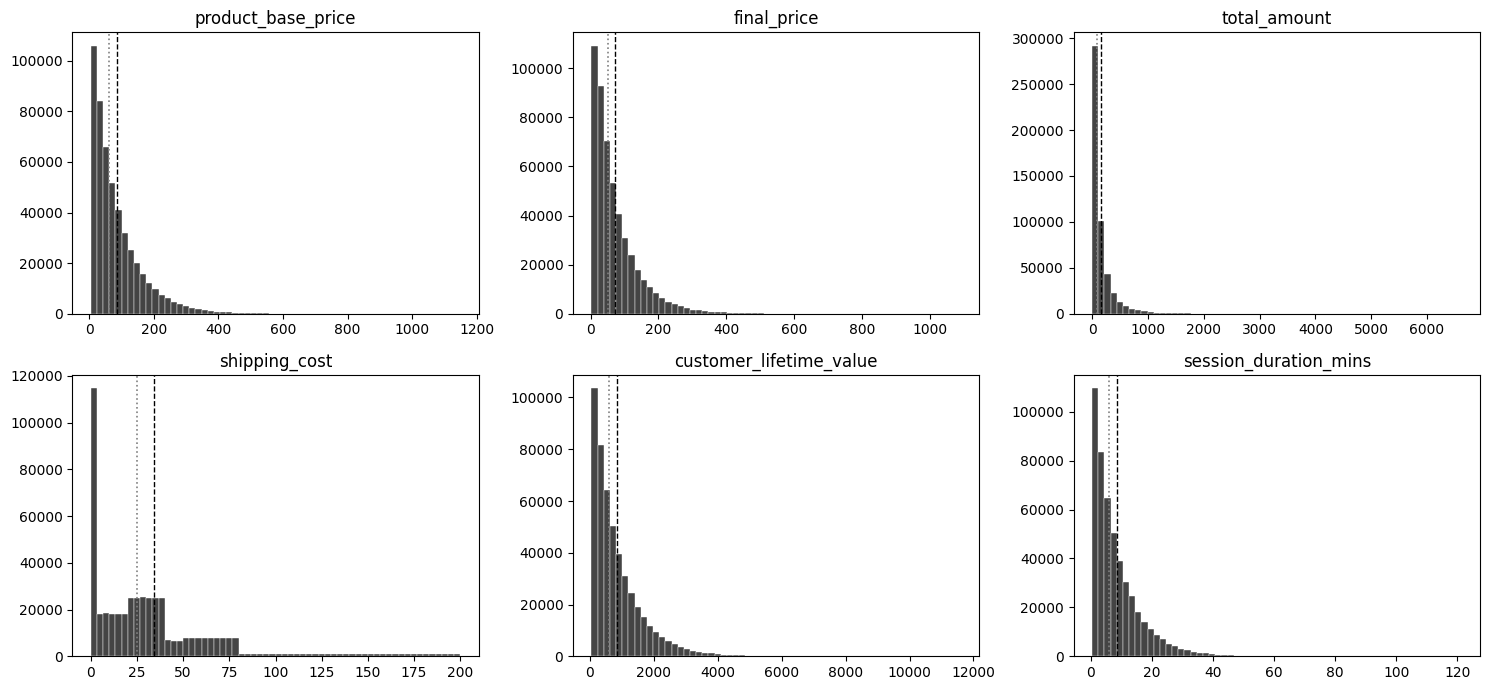

In [8]:
fig, axs = plt.subplots(2,3, figsize=(15,7))
for ax,m in zip(axs.ravel(), money):
    ax.hist(data[m].dropna(), bins=60, color='#444444', edgecolor='white', linewidth=.3)
    ax.axvline(data[m].mean(), color='black', ls='--', lw=1)
    ax.axvline(data[m].median(), color='gray', ls=':', lw=1.2)
    ax.set_title(m)
plt.tight_layout(); plt.show()

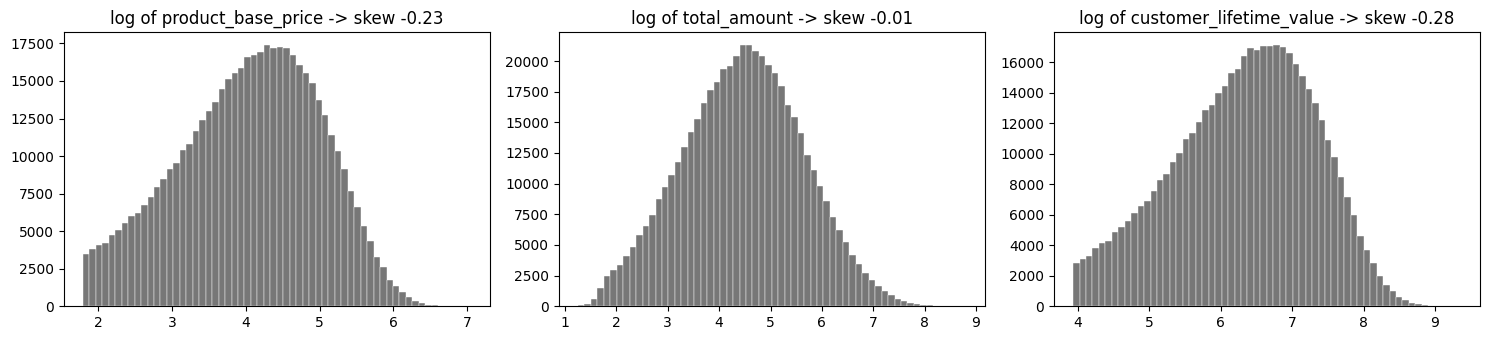

In [9]:
# applying log to see if the tail flattens
fig, axs = plt.subplots(1,3, figsize=(15,3.5))
for ax,m in zip(axs, ['product_base_price','total_amount','customer_lifetime_value']):
    v = data[m].dropna()
    ax.hist(np.log1p(v), bins=60, color='#777777', edgecolor='white', linewidth=.3)
    ax.set_title(f'log of {m} -> skew {stats.skew(np.log1p(v)):.2f}')
plt.tight_layout(); plt.show()

### 3. Inspecting categorical fields

In [10]:
cats = ['category','sub_category','shipping_method','payment_method',
        'customer_gender','country','city','loyalty_tier','return_reason']
for cat in cats:
    top = data[cat].mode()[0] if data[cat].notna().any() else 'NA'
    print(f'{cat:16s} levels={data[cat].nunique():4d}   common={top}')

category         levels=  10   common=Clothing
sub_category     levels=  45   common=Outdoor
shipping_method  levels=   4   common=Standard
payment_method   levels=   6   common=UPI


customer_gender  levels=   3   common=Female
country          levels=   8   common=India
city             levels=  15   common=Chennai
loyalty_tier     levels=   4   common=Bronze
return_reason    levels=   5   common=Not as Described


In [11]:
# checking if city values sit under the right country
for country, cities in data.groupby('country')['city'].agg(lambda s: sorted(s.unique())[:5]).items():
    print(f'{country:10s}: {cities}')

Australia : ['Bangalore', 'Berlin', 'Chennai', 'Chicago', 'Delhi']
Canada    : ['Bangalore', 'Berlin', 'Chennai', 'Chicago', 'Delhi']
France    : ['Bangalore', 'Berlin', 'Chennai', 'Chicago', 'Delhi']
Germany   : ['Bangalore', 'Berlin', 'Chennai', 'Chicago', 'Delhi']
India     : ['Bangalore', 'Berlin', 'Chennai', 'Chicago', 'Delhi']
UAE       : ['Bangalore', 'Berlin', 'Chennai', 'Chicago', 'Delhi']
UK        : ['Bangalore', 'Berlin', 'Chennai', 'Chicago', 'Delhi']
USA       : ['Bangalore', 'Berlin', 'Chennai', 'Chicago', 'Delhi']


### 4. Looking into returns

In [12]:
print('returned : %.2f%%' % (data.is_returned.mean()*100))
print('cancelled: %.2f%%' % (data.is_cancelled.mean()*100))
data.loc[data.is_returned==1,'return_reason'].value_counts()

returned : 11.98%
cancelled: 6.17%


return_reason
Not as Described      12080
Defective             12047
Wrong Item            11962
Better Price Found    11933
Changed Mind          11882
Name: count, dtype: int64

In [13]:
def returns_in(col, edges=None):
    grp = pd.cut(data[col], edges) if edges is not None else data[col]
    return (data.groupby(grp, observed=True).is_returned.mean()*100).round(2)

print(returns_in('rating',[0,2,3,4,5]), '\n')
print(returns_in('discount_percentage',[-1,0,10,20,30,50]), '\n')
print((data.groupby('category').is_returned.mean()*100).round(2).sort_values(ascending=False))

rating
(0, 2]    12.35
(2, 3]    12.11
(3, 4]    12.06
(4, 5]    11.77
Name: is_returned, dtype: float64 

discount_percentage
(-1, 0]     11.90
(0, 10]     12.01
(10, 20]    11.90
(20, 30]    11.94
(30, 50]    12.47
Name: is_returned, dtype: float64 

category
Electronics       12.11
Furniture         12.10
Beauty            12.06
Automotive        12.05
Books             12.04
Toys              11.94
Food & Grocery    11.93
Home & Kitchen    11.89
Sports            11.86
Clothing          11.82
Name: is_returned, dtype: float64


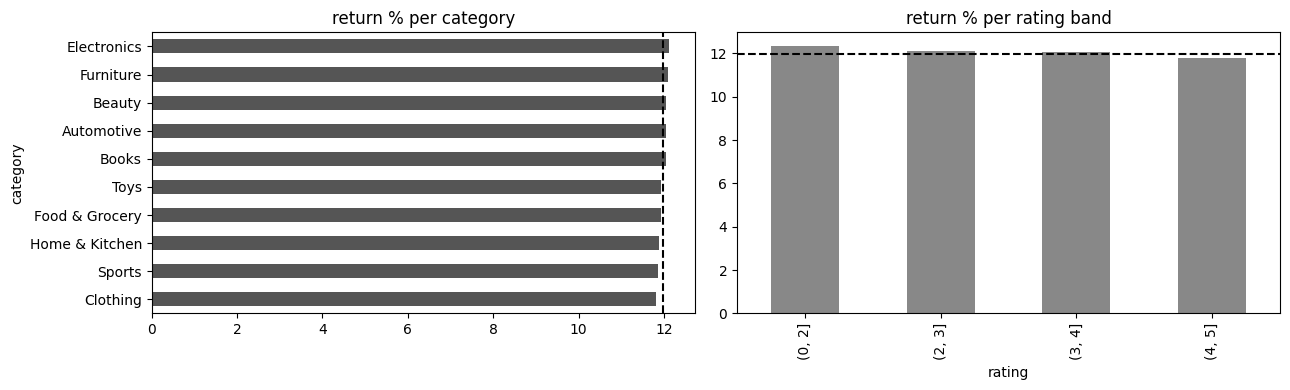

In [14]:
fig, axs = plt.subplots(1,2, figsize=(13,4))
(data.groupby('category').is_returned.mean()*100).sort_values().plot.barh(ax=axs[0], color='#555555')
axs[0].axvline(11.98, color='black', ls='--'); axs[0].set_title('return % per category')
returns_in('rating',[0,2,3,4,5]).plot.bar(ax=axs[1], color='#888888')
axs[1].axhline(11.98, color='black', ls='--'); axs[1].set_title('return % per rating band')
plt.tight_layout(); plt.show()

### 5. Building the preprocessing pipeline

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PowerTransformer, OneHotEncoder, OrdinalEncoder

heavy_tail = ['product_base_price','shipping_cost','customer_lifetime_value','session_duration_mins']
plain_num  = ['discount_percentage','quantity','days_to_deliver','rating','num_reviews',
              'customer_age','pages_viewed','clicks_to_purchase']
ranked_cat = ['loyalty_tier']
plain_cat  = ['category','sub_category','shipping_method','payment_method','customer_gender','country']
keep_asis  = ['is_first_purchase','is_cancelled']
# removed -> ids, order_date, final_price & total_amount (redundant), city (wrong geo), return_reason (leak)

branch_tail = Pipeline([('fill', SimpleImputer(strategy='median')),
                        ('pt', PowerTransformer()), ('std', StandardScaler())])
branch_num  = Pipeline([('fill', SimpleImputer(strategy='median')), ('std', StandardScaler())])
branch_rank = Pipeline([('fill', SimpleImputer(strategy='most_frequent')),
                        ('enc', OrdinalEncoder(categories=[['Bronze','Silver','Gold','Platinum']]))])
branch_cat  = Pipeline([('fill', SimpleImputer(strategy='most_frequent')),
                        ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

prep = ColumnTransformer([
    ('tail', branch_tail, heavy_tail),
    ('num',  branch_num,  plain_num),
    ('rank', branch_rank, ranked_cat),
    ('cat',  branch_cat,  plain_cat),
    ('keep', 'passthrough', keep_asis),
], remainder='drop')

In [16]:
features = data.drop(columns=['is_returned'])
target = data['is_returned']
M = prep.fit_transform(features)
print('matrix:', M.shape, ' has nan:', np.isnan(M).any())
cols_out = prep.get_feature_names_out()
len(cols_out)

matrix: (500000, 91)  has nan: False


91

### 6. Correlation and predictive power

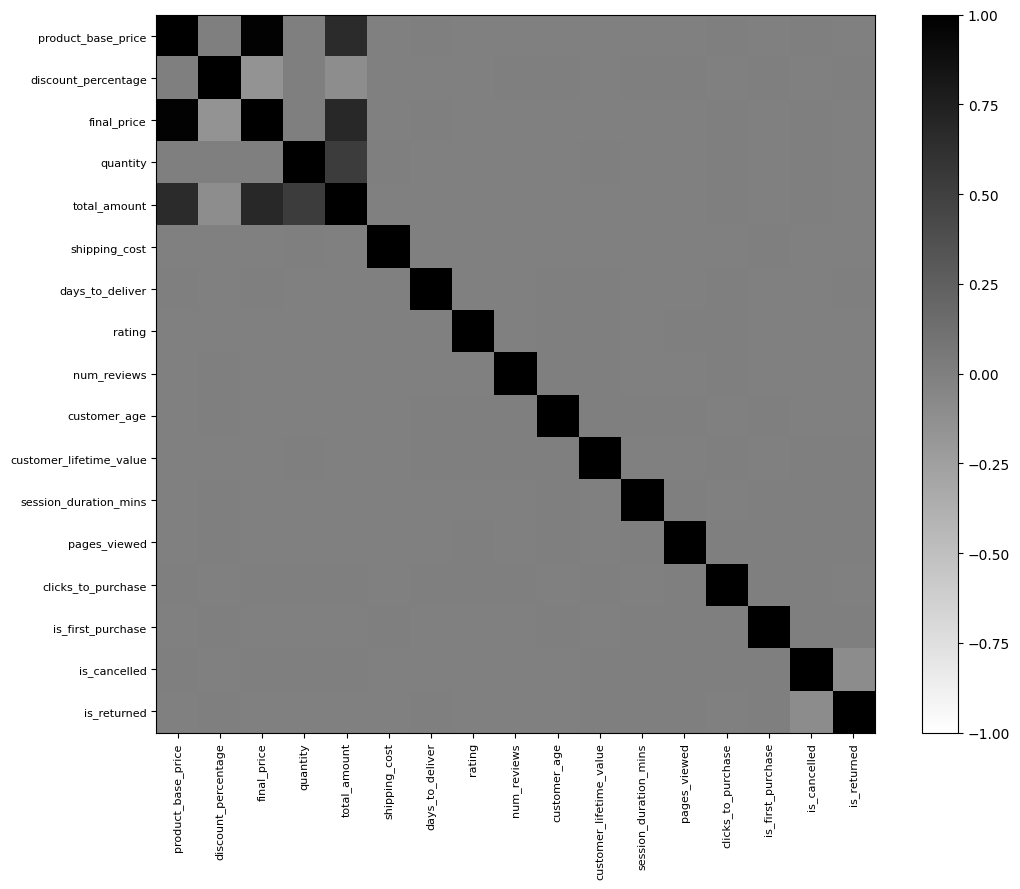

In [17]:
numeric = ['product_base_price','discount_percentage','final_price','quantity','total_amount',
           'shipping_cost','days_to_deliver','rating','num_reviews','customer_age',
           'customer_lifetime_value','session_duration_mins','pages_viewed','clicks_to_purchase',
           'is_first_purchase','is_cancelled','is_returned']
cmat = data[numeric].corr()

fig, ax = plt.subplots(figsize=(11,9))
hm = ax.imshow(cmat, cmap='gray_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric))); ax.set_xticklabels(numeric, rotation=90, fontsize=8)
ax.set_yticks(range(len(numeric))); ax.set_yticklabels(numeric, fontsize=8)
plt.colorbar(hm, fraction=0.046); plt.tight_layout(); plt.show()

In [18]:
# pairs that overlap heavily
sub = cmat.drop('is_returned').drop(columns='is_returned')
for a in sub.columns:
    for b in sub.columns:
        if a<b and abs(sub.loc[a,b])>0.5:
            print(f'{a:24s} & {b:22s} -> {sub.loc[a,b]:.3f}')
print()
cmat['is_returned'].drop('is_returned').abs().sort_values(ascending=False).round(4)

product_base_price       & total_amount           -> 0.660
final_price              & product_base_price     -> 0.976
final_price              & total_amount           -> 0.675
quantity                 & total_amount           -> 0.531



is_cancelled               0.0946
rating                     0.0045
discount_percentage        0.0027
session_duration_mins      0.0020
final_price                0.0016
total_amount               0.0015
pages_viewed               0.0013
product_base_price         0.0013
shipping_cost              0.0013
is_first_purchase          0.0010
clicks_to_purchase         0.0010
num_reviews                0.0009
customer_age               0.0007
days_to_deliver            0.0006
quantity                   0.0004
customer_lifetime_value    0.0002
Name: is_returned, dtype: float64

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

xtr,xte,ytr,yte = train_test_split(M,target,test_size=0.25,random_state=7,stratify=target)
model = RandomForestClassifier(n_estimators=120, max_depth=12, n_jobs=-1, random_state=7)
model.fit(xtr,ytr)
print('accuracy: %.3f   majority class: %.3f' % (model.score(xte,yte), 1-target.mean()))
pd.Series(model.feature_importances_, index=cols_out).sort_values(ascending=False).head(12)

accuracy: 0.880   majority class: 0.880


keep__is_cancelled               0.262850
tail__product_base_price         0.064398
tail__customer_lifetime_value    0.063474
tail__session_duration_mins      0.056035
num__num_reviews                 0.052076
tail__shipping_cost              0.051652
num__customer_age                0.045169
num__pages_viewed                0.043994
num__clicks_to_purchase          0.034520
num__days_to_deliver             0.028219
num__quantity                    0.025638
num__discount_percentage         0.025581
dtype: float64